
# 16. 기사로 여는 문: 실제 글과 만든 세계 부품이 한 문제에서 협력

**문제**: 안내판에 사슬이 있고, 열쇠마다 실제 답 후보 이름표가 붙어 있다(예: 해 열쇠 = "김선명"). 기준 문 하나의 열쇠는 **실제 KLUE 기사 질문의 정답이 적힌 열쇠**다. 출처들이 기사 원문(참 기사 또는 거짓 기사)을 건넨다.

**흐름**: 기사 읽기 → 실제 글 신뢰 → 이름표로 열쇠 찾기 → 연결 장치 → 생각 부품이 사슬을 따라감 → 답. **새로 학습한 것은 없다.**

| 종류 | 무엇을 묻나 |
|---|---|
| C | 사슬 끝. 안내판이 기사 문의 열쇠를 알려준다 |
| A | 기사 문 자체 |
| AC | 사슬 끝. 기사 문의 열쇠는 기사로만 알 수 있다 (처음 보는 조합) |


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
r = json.loads((S.RESULTS / "mk1-e_article_doors.json").read_text(encoding="utf-8"))
print(json.dumps(r["criteria"], ensure_ascii=False))


{"1_unseen_combination_AC": true, "2_chain_passes_without_loss": false, "3_no_needless_asks_C": true, "4_router_beats_fixed": true}


## 1. 사령탑은 기사 부품을 처음 보는데도 정답 길잡이와 똑같이 묻는다

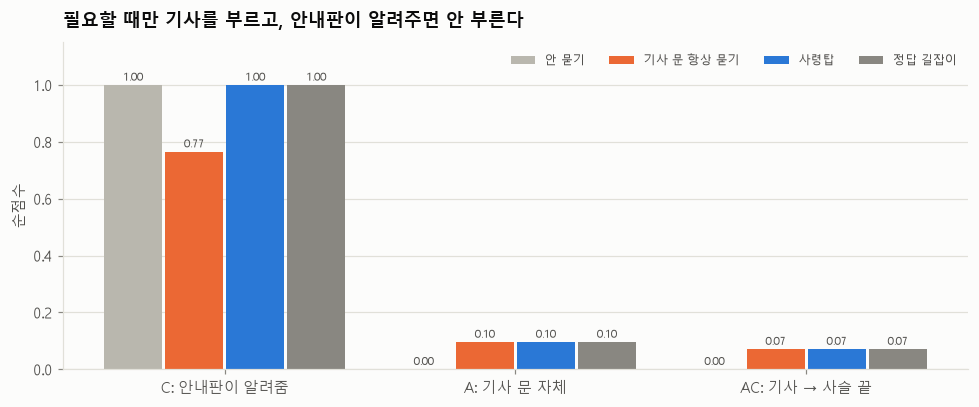

In [2]:

types = [("C", "C: 안내판이 알려줌"), ("A", "A: 기사 문 자체"), ("AC", "AC: 기사 → 사슬 끝")]
pols = [("think", "안 묻기", V.NEUTRAL), ("ask-available", "기사 문 항상 묻기", V.ORANGE), ("route", "사령탑", V.BLUE), ("oracle", "정답 길잡이", V.MUTED)]
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(types)); w = 0.2
for i, (p, label, color) in enumerate(pols):
    vals = [r["by_type"][t][p]["net"] for t, _ in types]
    ax.bar(x + (i - 1.5) * (w + 0.01), vals, width=w, color=color, label=label)
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 1.5) * (w + 0.01), v + 0.015, f"{v:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [l for _, l in types]); ax.set_ylim(0, 1.15); ax.grid(axis="x", visible=False)
ax.set_ylabel("순점수"); ax.legend(fontsize=8, frameon=False, ncol=4, loc="upper right")
ax.set_title("필요할 때만 기사를 부르고, 안내판이 알려주면 안 부른다", pad=10)
fig.tight_layout(); plt.show()


## 2. 실제 글에서 나온 결론은 사슬을 지나도 100% 그대로 전달된다

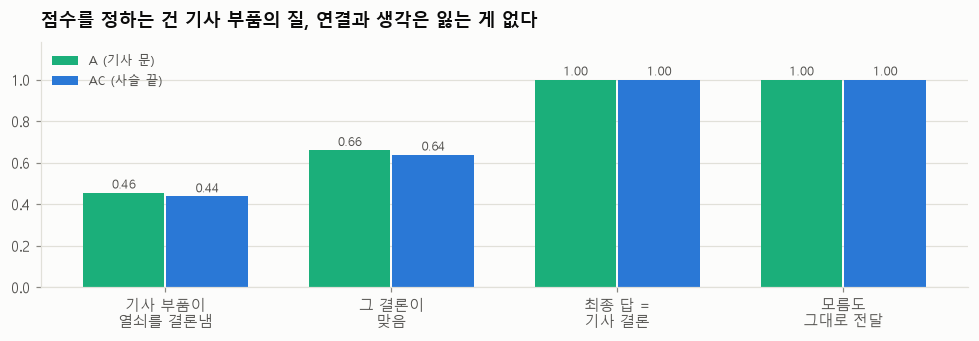

In [3]:

f = r["fidelity"]
fig, ax = plt.subplots(figsize=(9, 3.2))
names = [("article_concluded", "기사 부품이\n열쇠를 결론냄"), ("conclusion_right", "그 결론이\n맞음"), ("answer_equals_conclusion", "최종 답 =\n기사 결론"), ("unknown_passed_on", "모름도\n그대로 전달")]
x = np.arange(len(names)); w = 0.36
for i, (kind, color) in enumerate((("A", V.AQUA), ("AC", V.BLUE))):
    vals = [f[kind][k] for k, _ in names]
    ax.bar(x + (i - 0.5) * (w + 0.01), vals, width=w, color=color, label="A (기사 문)" if kind == "A" else "AC (사슬 끝)")
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 0.5) * (w + 0.01), v + 0.02, f"{v:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [l for _, l in names]); ax.set_ylim(0, 1.18); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, frameon=False, loc="upper left")
ax.set_title("점수를 정하는 건 기사 부품의 질, 연결과 생각은 잃는 게 없다", pad=10)
fig.tight_layout(); plt.show()



## 3. 정리

- **협력 성공**: 실제 한국어 기사 → 신뢰 판단 → 이름표 → 연결 → 사슬 추론이 학습 없이 이어졌다. 7단계 사령탑은 기사 부품을 본 적이 없는데도, 처음 보는 조합(AC)에서 정답 길잡이와 문제마다 똑같이 결정한다.
- **기준 2는 실패로 기록**: A와 AC 점수 차이 0.025(기준 0.02). 서로 다른 질문을 비교한 내 설계 실수다. 짝지어 재 보니 전달은 100% 충실했다.
- **새로 보인 약점**: 안내판과 기사가 서로 다른 열쇠를 말하면(C에서 억지로 물을 때 0.77) 생각 부품이 출처를 저울질하지 못한다. **출처 충돌 다루기**가 다음 과제 후보다.
